# 01 · Quickstart: fit a hyperplane tree on Branin

Train a `HyperplaneTreeRegressor` on the 2D Branin function, predict on
a grid, and visualise the surface and oblique splits.


In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jax_ldt import HyperplaneTreeRegressor, LinearTreeRegressor

print("jax", jax.__version__)


jax 0.9.0.1


## Generate Branin training data

In [2]:
def branin(x1, x2):
    a, b, c, r, s, t = 1.0, 5.1 / (4 * np.pi**2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r) ** 2 + s * (1 - t) * np.cos(x1) + s

rng = np.random.default_rng(0)
X_train = rng.uniform([-5.0, 0.0], [10.0, 15.0], size=(400, 2))
y_train = branin(X_train[:, 0], X_train[:, 1])
print(f"X_train: {X_train.shape}, y range: [{y_train.min():.2f}, {y_train.max():.2f}]")


X_train: (400, 2), y range: [0.49, 238.45]


## Fit both LMDT and HT, compare in-sample MAE

In [3]:
common = dict(max_depth=5, max_bins=8, min_samples_leaf=15, ridge=1e-5)

lmdt = LinearTreeRegressor(**common).fit(X_train, y_train)
ht = HyperplaneTreeRegressor(**common, max_weight=2, num_terms=2).fit(X_train, y_train)

mae_lmdt = float(jnp.mean(jnp.abs(lmdt.predict(X_train) - y_train)))
mae_ht = float(jnp.mean(jnp.abs(ht.predict(X_train) - y_train)))
print(f"LMDT MAE: {mae_lmdt:.3f}  ({lmdt.num_leaves} leaves)")
print(f"HT   MAE: {mae_ht:.3f}  ({ht.num_leaves} leaves)")


/Users/jkitchin/Dropbox/projects/jax-ldt/src/jax_ldt/hyperplanes.py:188: UserWarning: hyperplanes.symmetrize: rounded.dedup dropped 13 of 20 rows (kept 7) at tol_decimals=4. Consider increasing tol_decimals to preserve distinct directions.
  LCs_arr = symmetrize(LCs_arr, tol_decimals=tol_decimals)
/Users/jkitchin/Dropbox/projects/jax-ldt/src/jax_ldt/hyperplane_tree.py:139: UserWarning: hyperplanes.build_transform_matrix: rounded.dedup dropped 6 of 12 rows (kept 6) at tol_decimals=4. Consider increasing tol_decimals to preserve distinct directions.
  A = build_transform_matrix(


LMDT MAE: 2.548  (19 leaves)
HT   MAE: 3.068  (15 leaves)


## Plot true surface, LMDT and HT predictions

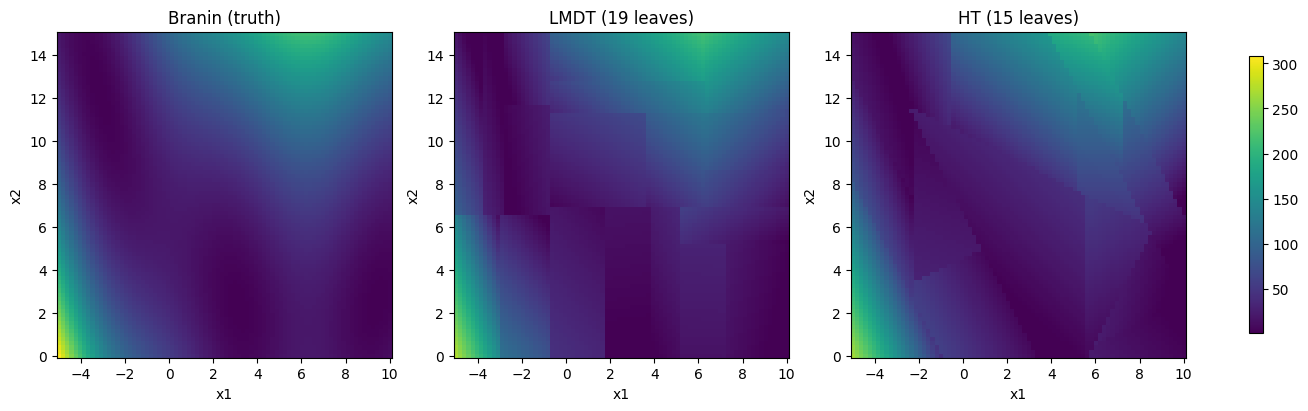

In [4]:
g = 80
xx, yy = np.meshgrid(
    np.linspace(-5, 10, g), np.linspace(0, 15, g)
)
Xg = np.column_stack([xx.ravel(), yy.ravel()])

zz_true = branin(xx, yy)
zz_lmdt = np.asarray(lmdt.predict(Xg)).reshape(xx.shape)
zz_ht = np.asarray(ht.predict(Xg)).reshape(xx.shape)

vmin, vmax = float(zz_true.min()), float(zz_true.max())
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, z, title in zip(
    axes,
    [zz_true, zz_lmdt, zz_ht],
    ["Branin (truth)", f"LMDT ({lmdt.num_leaves} leaves)", f"HT ({ht.num_leaves} leaves)"],
):
    im = ax.pcolormesh(xx, yy, z, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
fig.colorbar(im, ax=axes, shrink=0.85)
plt.show()


## What just happened?

* `LinearTreeRegressor` fits axis-aligned splits with a linear regression at every leaf.
* `HyperplaneTreeRegressor` lifts X via a learned set of integer-weight directions (`max_weight=2`, `num_terms=2`) and fits the same kind of tree on the lifted features. Splits can now follow oblique angles.
* On Branin the two are comparable at this leaf budget — Branin's curvature is mostly axis-aligned around its three minima, so the oblique splits don't help much. HT pays off more clearly when the target has diagonal structure (e.g., `y = sin(x0 + x1)`); see notebook 06 for a steam-table example where HT wins decisively.
